In [20]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [21]:
filename='BaseTARGET_PPDPLUS_Mayo2026_REAG.csv'


In [ ]:
query = f"""
    SELECT *,NumDoc as DNI
  FROM [DANTALION].[dbo].[Base_Maestra_Diners]
  where FECHA_ENVIO>='2026-05-01'
and marca='ppd plus'

      """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [23]:

filename='BaseTARGET_PPDPLUS_Mayo2026_REAG.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)


In [24]:
from pyspark.sql import functions as F

exprs = [
    F.count(F.when(F.col(c).isNotNull(), c)).alias(c)
    for c in df_prueba.columns
]

df_counts = df_prueba.agg(*exprs).collect()[0].asDict()

cols_con_data = [c for c, v in df_counts.items() if v > 0]

df_prueba = df_prueba.select(cols_con_data)

In [ ]:
df_prueba=df_prueba.withColumnRenamed('CANAL_ASIGNADO','LIDER_CARTERA')
df_prueba=df_prueba.withColumnRenamed('DNI','NumDoc')
df_prueba=df_prueba.withColumnRenamed('ASESOR_ASIGNADO','ASESOR_CARTER')
df_prueba=df_prueba.withColumnRenamed('Deuda_tc_Continental','Deuda_Continental')
df_prueba=df_prueba.withColumnRenamed('Deuda_tc_Interbank','Deuda_Interbank')
df_prueba=df_prueba.withColumnRenamed('Deuda_tc_BCP','Deuda_BCP')
df_prueba=df_prueba.withColumnRenamed('Deuda_tc_falabella','Deuda_Otros')
df_prueba=df_prueba.withColumnRenamed('Deuda_tc_ScotiaBank','Deuda_ScotiaBank')
df_prueba=df_prueba.withColumnRenamed('appaterno','ApPaterno')
df_prueba=df_prueba.withColumnRenamed('TEA','TEA_FORMATO')
df_prueba=df_prueba.withColumnRenamed('TEM','TEM_FORMATO')
df_prueba=df_prueba.withColumnRenamed('TEM','TEM_FORMATO')
df_prueba=df_prueba.withColumnRenamed('NUMERO_TELEFONO','Tel1')

df_prueba=df_prueba.withColumnRenamed('TOTAL_DEUDA_BANCOS','saldo_ppd')
df_prueba=df_prueba.withColumnRenamed('RECURRENCIA_DIGITAL','MARCA3')
df_prueba=df_prueba.withColumnRenamed('CLAVE_WEB','MARCA4')
df_prueba=df_prueba.withColumnRenamed('TEA_ANTERIOR','TEA_PPD')
df_prueba=df_prueba.withColumnRenamed('MONTO_PPD','Linea_EI_60M')

df_prueba=df_prueba.withColumnRenamed('SALDO_PPD','saldo_ppd')
df_prueba=df_prueba.withColumnRenamed('prioridad_PPD','prioridad_inicial')
df_prueba=df_prueba.withColumnRenamed('TASAINTERES','TASA_MACRO')

In [ ]:




Deuda_tc_total

In [13]:
print(df_formato.columns)
print(df_prueba.columns)

['Nro_Tarjeta', 'NumDoc', 'CUS1', 'IdenCuenta', 'Probabilidad', 'Nombre_Producto', 'TipoTarjeta', 'Estado_Tarjeta', 'TEA_FORMATO', 'TEM_FORMATO', 'saldo_ppd', 'cuota_mensual', 'nrocuotas_rest', 'Linea_EI_60M', 'speech', 'prioridad_inicial', 'Deuda_BCP', 'Deuda_Continental', 'Deuda_ScotiaBank', 'Deuda_Interbank', 'Deuda_Otros', 'Fecha_Expiracion', 'Tel1', 'Tel2', 'Tel3', 'Tel4', 'Nombre_Largo', 'Nombre', 'ApPaterno', 'ApMaterno', 'Ciclo', 'FechaNacimiento', 'Nacionalidad', 'EstadoCivil', 'Conyuge', 'Alerta_Diners', 'Direccion_Correspondencia', 'Distrito_Correspondencia', 'Provincia_Correspondencia', 'Departamento_Correspondencia', 'Direccion_Domicilio', 'Distrito', 'Provincia', 'Departamento', 'RazonSocial_Empresa', 'RUC_Empresa', 'Cargo', 'Profesion', 'Direccion_Lab', 'Distrito_Lab', 'Provincia_Lab', 'Departamento_Lab', 'gestion_call', 'Flag_entrega', 'mes_entrega', 'FLAG_ADICION', 'FLAG_CAD', 'flag_claveweb', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_RIP', 'L_CMR', 'L

In [30]:
df_formato = df_formato.withColumn(
    "NumDoc",
    F.right(
        F.concat(F.lit("00000000"), F.col("NumDoc")),
        F.lit(8)
    )
)

df_prueba = df_prueba.withColumn(
    "NumDoc",
    F.right(
        F.concat(F.lit("00000000"), F.col("NumDoc")),
        F.lit(8)
    )
)


In [37]:
df_prueba=df_prueba.drop('FLG_UPD', 'TIPO_CAMPAÑA_PPD', 'Deuda_tc_total', 'CORREO')

In [27]:
print(df_formato.columns)
print(df_prueba.columns)

['Nro_Tarjeta', 'NumDoc', 'CUS1', 'IdenCuenta', 'Probabilidad', 'Nombre_Producto', 'TipoTarjeta', 'Estado_Tarjeta', 'TEA_FORMATO', 'TEM_FORMATO', 'saldo_ppd', 'cuota_mensual', 'nrocuotas_rest', 'Linea_EI_60M', 'speech', 'prioridad_inicial', 'Deuda_BCP', 'Deuda_Continental', 'Deuda_ScotiaBank', 'Deuda_Interbank', 'Deuda_Otros', 'Fecha_Expiracion', 'Tel1', 'Tel2', 'Tel3', 'Tel4', 'Nombre_Largo', 'Nombre', 'ApPaterno', 'ApMaterno', 'Ciclo', 'FechaNacimiento', 'Nacionalidad', 'EstadoCivil', 'Conyuge', 'Alerta_Diners', 'Direccion_Correspondencia', 'Distrito_Correspondencia', 'Provincia_Correspondencia', 'Departamento_Correspondencia', 'Direccion_Domicilio', 'Distrito', 'Provincia', 'Departamento', 'RazonSocial_Empresa', 'RUC_Empresa', 'Cargo', 'Profesion', 'Direccion_Lab', 'Distrito_Lab', 'Provincia_Lab', 'Departamento_Lab', 'gestion_call', 'Flag_entrega', 'mes_entrega', 'FLAG_ADICION', 'FLAG_CAD', 'flag_claveweb', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_RIP', 'L_CMR', 'L

In [ ]:
['Nro_Tarjeta', 'NumDoc', 'IdenCuenta', 'Nombre_Producto', 'TIPO_CAMPAÑA_PPD', 'TipoTarjeta', 'Estado_Tarjeta', 'TEA_FORMATO', 'TEM_FORMATO', 'MONTO_PPD', 'prioridad_PPD', 'Deuda_tc_BCP', 'Deuda_tc_Continental', 'Deuda_tc_ScotiaBank', 'Deuda_tc_Interbank', 'Deuda_tc_falabella', 'Deuda_tc_total', 'Fecha_Expiracion', 'Tel1', 'Tel2', 'Nombre_Largo', 'Nombre', 'ApPaterno', 'ApMaterno', 'Ciclo', 'FechaNacimiento', 'Nacionalidad', 'EstadoCivil', 'Direccion_Correspondencia', 'Distrito_Correspondencia', 'Provincia_Correspondencia', 'Departamento_Correspondencia', 'Direccion_Domicilio', 'Distrito', 'Provincia', 'Departamento', 'RazonSocial_Empresa', 'RUC_Empresa', 'Cargo', 'Profesion', 'Direccion_Lab', 'Distrito_Lab', 'Provincia_Lab', 'Departamento_Lab', 'Flag_entrega', 'mes_entrega', 'FLAG_ADICION', 'FLAG_CAD', 'NOMBRE_adic1', 'ApPaterno1', 'ApMaterno1', 'NOMBRE_adic2', 'ApPaterno2', 'ApMaterno2', 'NOMBRE_adic3', 'ApPaterno3', 'ApMaterno3', 'NOMBRE_adic4', 'ApPaterno4', 'ApMaterno4', 'MARCA4', 'CORREO', 'MARCA3', 'SALDO_PPD', 'LIDER_CARTERA', 'ASESOR_CARTER', 'DNI_ASESOR', 'RECENCIA', 'FLG_UPD', 'TASAINTERES', 'TASA_APP', 'TEA_ANTERIOR']



In [38]:
cols_prueba = set(df_prueba.columns)
cols_formato = set(df_formato.columns)

solo_en_prueba = cols_prueba - cols_formato
print("Solo en df_prueba:", solo_en_prueba)

Solo en df_prueba: set()


In [34]:
df_prueba.select(
'TIPO_CAMPAÑA_PPD', 'CORREO', 'prioridad_PPD', 'FLG_UPD', 'Deuda_tc_total'
).show()
    

+----------------+--------------------+-------------+-------+--------------+
|TIPO_CAMPAÑA_PPD|              CORREO|prioridad_PPD|FLG_UPD|Deuda_tc_total|
+----------------+--------------------+-------------+-------+--------------+
|        PPD PLUS|ROSAAYAL40@GMAIL.COM|     3.Rosado|      0|       5928.69|
|        PPD PLUS|  APRILE87@GMAIL.COM|   2.Amarillo|      0|       1655.59|
|        PPD PLUS|JAIMETIPESANCHEZ@...|      1.Verde|      0|       6231.29|
|        PPD PLUS|carlosenriquelina...|      1.Verde|      0|      15249.66|
|        PPD PLUS|ELVIBRETO@HOTMAIL...|     7.Blanco|      0|             0|
|        PPD PLUS|EARICOCHEAV@GMAIL...|      1.Verde|      0|      13998.84|
|        PPD PLUS|DIANA.BAZAN@PUCP....|   6.SinColor|      0|             0|
|        PPD PLUS|DIANA.BAZAN@PUCP....|     7.Blanco|      0|             0|
|        PPD PLUS|marialuisadulanto...|     7.Blanco|      0|             0|
|        PPD PLUS|FLORHUAPRA_4@HOTM...|     7.Blanco|      0|             0|

In [39]:
df_prueba=df_prueba.withColumn('MARCA',F.lit('PPD PLUS'))
df_prueba=df_prueba.withColumn('MPPD',F.lit('PPD PLUS'))
df_prueba=df_prueba.withColumn('AÑO_DURACION_BASE',F.lit('2026'))
df_prueba=df_prueba.withColumn('MES_DURACION_BASE',F.lit('05'))
df_prueba=df_prueba.withColumn('SERVICIO',F.lit('01'))
df_prueba=df_prueba.withColumn('FECHA_ENVIO',F.lit('2026-05-27'))

In [45]:
df_prueba.count()

491

In [69]:
df_prueba=df_prueba.join(df_formato,['NumDoc'],'leftanti')

In [68]:
df_prueba.select('NumDoc').join(df_formato,['NumDoc'],'inner').count()


271

In [60]:
df_formato.select('marca').distinct().show()

+--------+
|   marca|
+--------+
|PPD PLUS|
+--------+



In [70]:
append_table_SQL(spark,df_prueba,f'Base_Maestra_Diners',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [39]:
from pyspark.sql import functions as F

df_prueba = df_prueba.withColumn(
    "CEL01",
    F.when(F.col("Tel1").rlike(r"^9\d{0,8}$"), F.col("Tel1"))
)


In [24]:
df_list_filtrada = df_prueba.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'prueba.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
# append_table_SQL(spark,df_prueba,f'Base_Maestra_Diners',server_kishin,user_kishin,pwd_kishin,'DANTALION')


## desde aqui

In [ ]:
query = f"""
    SELECT
      Distinct [NumDoc] as DNI
      ,CONVERT(date, CAST(FechaNacimiento AS varchar(8))) AS fec_nac
    ,TRY_CAST(REPLACE(NULLIF(REPLACE(TRIM(tasa_app), '-', ''),''),',','.') AS FLOAT) / 100 AS tasa_app
  FROM [DANTALION].[dbo].[Base_Maestra_Diners_Vigente]
      """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

filename='BasePPD_TARGET_RECENCIA_DIGITAL_Abril2026.csv'
df_radiografia=cargar_archivo_csv(spark,filename,';',True)
df_radiografia=df_radiografia.drop('TASA_APP')

df_formato = df_formato.withColumn(
    "dni",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)

df_radiografia = df_radiografia.withColumn(
    "dni",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)
df_radiografia=df_radiografia.join(df_formato,['DNI'],'left')

window_spec = Window.partitionBy("DNI",'fecha_ref').orderBy(F.col("fecha_ref").asc_nulls_first())
df_radiografia = df_radiografia.withColumn("tipo_registro_envio", row_number().over(window_spec))

window_spec = Window.partitionBy("DNI").orderBy(F.col("fecha_ref").asc_nulls_first())
df_radiografia = df_radiografia.withColumn("tipo_registro", row_number().over(window_spec))
df_radiografia = df_radiografia.withColumn(
    "tipo_registro_01",
     F.when((F.col("tipo_registro_envio")>1), "duplicado_envio")
    .when(F.col("tipo_registro")==1, "unico")
    .otherwise("Duplicado")
)

cond_valido = (
    F.col("Tel1").rlike(r"^9\d{8}$") |
    F.col("Tel2").rlike(r"^9\d{8}$") |
    F.col("Tel3").rlike(r"^9\d{8}$")
)

cond_sin_tel = (
    (F.col("Tel1").isNull() | (F.col("Tel1") == "")) &
    (F.col("Tel2").isNull() | (F.col("Tel2") == "")) &
    (F.col("Tel3").isNull() | (F.col("Tel3") == ""))
)

df_radiografia = df_radiografia.withColumn(
    "TIPO_TELEFONO",
    F.when(cond_valido, "VALIDO")
     .when(cond_sin_tel, "SIN TELEFONO")
     .otherwise("NO VALIDO")
)
df_radiografia=df_radiografia.withColumn('MONTO_PPD',F.col("MONTO_PPD").cast("double"))

df_radiografia = df_radiografia.withColumn(
    "seg_MONTO_PPD",
    F.when(F.col("MONTO_PPD") < 10000, "a. [0,10k)")
    .when((F.col("MONTO_PPD") >= 10000) & (F.col("MONTO_PPD") < 20000), "b. [10k,20k)")
    .when((F.col("MONTO_PPD") >= 20000) & (F.col("MONTO_PPD") < 30000), "c. [20k,30k)")
    .when((F.col("MONTO_PPD") >= 30000) & (F.col("MONTO_PPD") < 40000), "d. [30k,40k)")
    .when((F.col("MONTO_PPD") >= 40000) & (F.col("MONTO_PPD") < 50000), "e. [40k,50k)")
    .when((F.col("MONTO_PPD") >= 50000) & (F.col("MONTO_PPD") < 60000), "f. [50k,60k)")
    .when((F.col("MONTO_PPD") >= 60000) & (F.col("MONTO_PPD") < 70000), "g. [60k,70k)")
    .when((F.col("MONTO_PPD") >= 70000) & (F.col("MONTO_PPD") < 80000), "h. [70k,80k)")
    .when((F.col("MONTO_PPD") >= 80000) & (F.col("MONTO_PPD") < 90000), "i. [80k,90k)")
    .when(F.col("MONTO_PPD") >= 90000, "j. [90k,+)")
    .otherwise("z. otros")
)
df_radiografia=df_radiografia.withColumn(
        "TEA_FORMATO_REAL",
        F.expr("""
            try_cast(
                regexp_replace(trim(TEA_FORMATO), '%', '')
                as double
            ) / 100
        """)
    )

df_radiografia=df_radiografia.withColumn(
        "TEA_FORMATO_REAL",
        F.expr("""
            try_cast(
                regexp_replace(trim(TEA_FORMATO), '%', '')
                as double
            ) / 100
        """)
    )


df_radiografia = df_radiografia.withColumn(
    "seg_TEA_FORMATO",
    F.when(F.col("TEA_FORMATO_REAL") < 0.10, "a. [0%,10%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.10) & (F.col("TEA_FORMATO_REAL") < 0.15), "b. [10%,15%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.15) & (F.col("TEA_FORMATO_REAL") < 0.20), "c. [15%,20%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.20) & (F.col("TEA_FORMATO_REAL") < 0.25), "d. [20%,25%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.25) & (F.col("TEA_FORMATO_REAL") < 0.30), "e. [25%,30%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.30) & (F.col("TEA_FORMATO_REAL") < 0.35), "f. [30%,35%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.35) & (F.col("TEA_FORMATO_REAL") < 0.40), "g. [35%,40%)")
    .when((F.col("TEA_FORMATO_REAL") >= 0.40) & (F.col("TEA_FORMATO_REAL") < 0.45), "h. [40%,45%)")
    .when(F.col("TEA_FORMATO_REAL") >= 0.45, "i. [45%,+)")
    .otherwise("z. otros")
)

In [82]:

df_radiografia.show(3)


+--------+--------------+----+----------+------------+---------------+-----------+--------------+-----------+-----------+---------+-------------+------------+--------------------+-------------------+------------------+------------------+--------------+----------------+---------+--------+----+----+--------------------+--------+---------+----------------+-----+---------------+------------+--------------------+-------+-------------+-------------------------+------------------------+-------------------------+----------------------------+--------------------+-----------------+---------+------------+--------------------+-----------+--------------------+--------------------+--------------------+-----------------+-------------+----------------+------------+-----------+------------------+------------+------------+----------+----------+------------+----------+----------+------------+----------+----------+------------+----------+----------+------------+----------+----------+-------------+--------

In [100]:

df_radiografia = df_radiografia.withColumn(
    'edad',
    F.floor(F.months_between(F.current_date(), F.col("fec_nac")) / 12)
)
df_radiografia = df_radiografia.withColumn(
    "seg_edad",
    F.when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 20) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 30), "a. 20 A 30")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 30) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 40), "b. 30 A 40")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 40) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 50), "c. 40 A 50")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 50) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 60), "d. 50 A 60")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 60) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 76), "e. 60 A 70")
    .otherwise('f. Otros')
)


df_radiografia = df_radiografia.withColumn(
    "seg_tasa_app",
    F.when(F.col("tasa_app") < 0.10, "a. [0%,10%)")
    .when((F.col("tasa_app") >= 0.10) & (F.col("tasa_app") < 0.15), "b. [10%,15%)")
    .when((F.col("tasa_app") >= 0.15) & (F.col("tasa_app") < 0.20), "c. [15%,20%)")
    .when((F.col("tasa_app") >= 0.20) & (F.col("tasa_app") < 0.25), "d. [20%,25%)")
    .when((F.col("tasa_app") >= 0.25) & (F.col("tasa_app") < 0.30), "e. [25%,30%)")
    .when((F.col("tasa_app") >= 0.30) & (F.col("tasa_app") < 0.35), "f. [30%,35%)")
    .when((F.col("tasa_app") >= 0.35) & (F.col("tasa_app") < 0.40), "g. [35%,40%)")
    .when(F.col("tasa_app") >= 0.40, "h. [40%,+)")
    .otherwise("z. otros")
)


In [84]:
df_radiografia.show(5)

+--------+--------------+----+----------+------------+---------------+-----------+--------------+-----------+-----------+---------+-------------+------------+--------------------+-------------------+------------------+------------------+--------------+----------------+---------+--------+---------+----+--------------------+--------+---------+----------------+-----+---------------+------------+--------------------+-------+-------------+-------------------------+------------------------+-------------------------+----------------------------+--------------------+-----------------+---------+------------+--------------------+-----------+--------------------+--------------------+--------------------+-----------------+-------------+----------------+------------+-----------+------------------+------------+------------+----------+----------+------------+----------+----------+------------+----------+----------+------------+----------+----------+------------+----------+----------+-------------+---

In [101]:
df_radiografia_pd = df_radiografia.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'radiografia_dinners_pp.xlsx')
df_radiografia_pd.to_excel(ruta_archivo, index=False)

In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO']

In [2]:
filename='ultimo_dinners.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)

df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)
df_prueba.show()

+----------------+----------------+---------+
|NUMERO_DOCUMENTO|FECHA_NACIMIENTO|LINEA_DIN|
+----------------+----------------+---------+
|        41387698|      1982-06-29|     1000|
|        41375323|      1982-02-14|     1000|
|        41389900|      1982-05-17|    10300|
|        07636038|      1975-02-06|     1300|
|        41147062|      1981-09-25|     4000|
|        41060990|      1981-09-16|     1000|
|        40908688|      1981-02-17|     1000|
|        40083351|      1978-02-18|     2400|
|        40015574|      1978-03-30|     1000|
|        32989335|      1978-03-07|     1000|
|        40821812|      1981-03-23|    10900|
|        40780419|      1980-11-23|     1000|
|        40711523|      1980-08-20|     8500|
|        32921330|      1970-01-30|     1000|
|        41264621|      1982-05-23|     1000|
|        41213918|      1982-06-07|     3600|
|        41080628|      1980-11-14|     1000|
|        41116889|      1981-01-01|     6800|
|        41035424|      1981-02-05

In [ ]:
# append_table_SQL(spark,df_prueba,f'borrar_dinnrs',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [23]:
cols_validas = [c for c in solo_en_formato if c in df_prueba.columns]

df_prueba.select(cols_validas).show()

++
||
++
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
++
only showing top 20 rows


In [4]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)



In [5]:
df_prueba.show(5)

+------------+-----------+----------------+----------------+-----------------+----------------+---------+-------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+-------------+-------------+-----------+-----------+-----------+-----------+-----------+-------------------+-------------------+-------------------+-------------------+-------------------+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+--------+---------+--------+---------+--------------------+--------+--------------+----------+----------------+---------+----------+------+------+-----+-----+------+-----+-----+-----+--------+-----+-----+-----+-----+-----+-----+-----+--------+------------------+-----------------+
|ID PROVEEDOR|    NOMBRES|APELLIDO PATERNO|APELLIDO MATERNO|TIPO DE DOCUMENTO|NUMERO_DOCUMENTO|TASA(TEA)| TEA_DF|TELEFONO_CASA1|TELEFONO_

In [ ]:
['CODIGO_BASE', 'DOCUMENTOS', 'SEGMENTO', 'TIPDOC', 'CODDOC', 'NOMBRE', 'APATERNO', 'AMATERNO', 'FIJO1', 'FIJO2', 'FIJO3', 'FIJO4', 'FIJO5', 'FIJO6', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'RNG_SALDO_TC', 'RNG_SALDO_CONSUMO', 'NUM_TC', 'RNG_LINEA_MAX_TC', 'RNG_SUMA_LINEA_TC', 'LINEA_CENCOSUD', 'RNG_LINEA_CENCOSUD', 'TIPO_TARJETA_CENCO', 'RNG_LIN_CENCO_ENTRE_LIN_MAX', 'RNG_SALDO_CONSUMO_ENTRE_INGRESO', 'RNG_SALDO_TC_ENTRE_INGRESO', 'RNG_EDAD', 'REGIMEN_LABORAL', 'RNG_INGRESO', 'DISTRITO', 'DEPARTAMENTO_A', 'DEPARTAMENTO_B', 'DISP_EFECTIVO_100', 'PROPENSION_EFECTIVO', 'SEG_CONTACT', 'FLG_CLIENTE_NUEVO', 'FLG_FRESCURA', 'FLG_EX_CLIENTE', 'MESES_ANTIGUEDAD_ULT_TC', 'QUINTIL_PROPENSION', 'TIPO_OFERTA', 'PROPENSION_SAE', 'LINEA_SAE', 'PCT', 'TEA', 'FLG_TOP_HABITUAL', 'FLG_TASA_ESPECIAL', 'FRECUENCIA_COMPRA', 'SEGMENTO_TLMK', 'FLG_MEJORA_OFERTA']cel

In [ ]:
df_prueba = df_prueba.withColumn("CELULAR1", F.col("Agencia_comercial"))


In [ ]:
df_prueba = df_prueba.withColumn("TIENDA", F.col("Agencia_comercial"))
df_prueba = df_prueba.withColumn("SUCURSAL", F.col("Agencia_comercial"))
df_prueba = df_prueba.withColumn("LOTE", F.lit("BASE 2026-04-016"))
df_prueba = df_prueba.withColumn("cl_base", F.lit("Abril 2026"))
df_prueba = df_prueba.withColumn("cl_carga", F.lit("2026-04-16"))
df_prueba = df_prueba.withColumn("ESTADO", F.lit("ACTIVO"))
df_prueba = df_prueba.withColumn("CAMPANA", F.lit("202604"))
df_prueba = df_prueba.withColumn("nombre_base", F.lit("2026-04-16"))

In [ ]:
cols_deseadas = [
    'CODIGO_BASE', 'DOCUMENTOS', 'SEGMENTO', 'TIPDOC', 'CODDOC',
    'NOMBRE', 'APATERNO', 'AMATERNO',
    'FIJO1', 'FIJO2', 'FIJO3', 'FIJO4', 'FIJO5', 'FIJO6',
    'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6',
    'RNG_SALDO_TC', 'RNG_SALDO_CONSUMO', 'NUM_TC',
    'RNG_LINEA_MAX_TC', 'RNG_SUMA_LINEA_TC',
    'LINEA_CENCOSUD', 'RNG_LINEA_CENCOSUD', 'TIPO_TARJETA_CENCO',
    'RNG_LIN_CENCO_ENTRE_LIN_MAX',
    'RNG_SALDO_CONSUMO_ENTRE_INGRESO', 'RNG_SALDO_TC_ENTRE_INGRESO',
    'RNG_EDAD', 'REGIMEN_LABORAL', 'RNG_INGRESO',
    'DISTRITO', 'DEPARTAMENTO_A', 'DEPARTAMENTO_B',
    'DISP_EFECTIVO_100', 'PROPENSION_EFECTIVO', 'SEG_CONTACT',
    'FLG_CLIENTE_NUEVO', 'FLG_EX_CLIENTE',
    'MESES_ANTIGUEDAD_ULT_TC', 'QUINTIL_PROPENSION', 'PROPENSION_SAE',
    'LINEA_SAE', 'TEA',
    'MARCA', 'MARCA2',
    'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08',
    'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8',
    'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE',
    'SERVICIO', 'RETIRO',
    'FLAT1', 'FLAT2', 'FLAT3',
    'REP1', 'REP2', 'DEVUELTO', 'REP3',
    'FRECUENCIA_COMPRA',
    'FLG_FRESCURA', 'FLG_MEJORA_OFERTA'
]

In [8]:
df_prueba=df_prueba.join(df_score,['NUMERO_DOCUMENTO'],'left')
print(df_prueba.columns)


['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA', 'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA', 'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO']


In [ ]:
# Lista de columnas que quieres (en TU orden)
cols_deseadas = [
    'NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO',
    'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO',
    'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL',
    'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final',
    'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
    'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL',
    'VARIACION_OFERTA_CAMPAÑA_ANTERIOR', 'VARIACION_TASA_CAMPAÑA_ANTERIOR',
    'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA',
    'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3',
    'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD',
    'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH',
    'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA',
    'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO'
]

# 1. Filtrar solo columnas que existen (manteniendo orden)
cols_validas = [c for c in cols_deseadas if c in df_prueba.columns]

# 2. Ver columnas que NO existen (debug opcional)
faltantes = [c for c in cols_deseadas if c not in df_prueba.columns]
print("Columnas no encontradas:", faltantes)

# 3. Seleccionar columnas en el orden deseado
df_prueba = df_prueba.select(cols_validas)

# 4. Ver resultado

Columnas no encontradas: ['VARIACION_OFERTA_CAMPAÑA_ANTERIOR', 'VARIACION_TASA_CAMPAÑA_ANTERIOR']


In [ ]:
select * 
into #BASE_ALFIN
from openquery([192.168.3.90],'Select cl_id, TIPO_DOI, NUMERO_DOCUMENTO, NOMBRES, APELLIDO_PATERNO, APELLIDO_MATERNO, SUCURSAL, TIENDA, DEPARTAMENTO, PROVINCIA, DISTRITO, FEC_NACIMIENTO, OFERTA_MAX, OFERTA_REEN, Tipo_verificacion, GRUPO_RIESGO, proveedor, lote, estado, Tasa_1,Tasa_2, Tasa_3, Tasa_4, Tasa_5, Tasa_6, Tasa_7, segmento, Campana, PLAZO, TEM, PROPENSION_IC, Desgravamen, CUOTA, Edad, Oferta_12M, Tasa_12M,Desgravamen_12M, CUOTA_12M, Oferta_18M, Tasa_18M, Desgravamen_18M, CUOTA_18M, Oferta_24M, Tasa_24M, Desgravamen_24M, CUOTA_24M, Oferta_36M, Tasa_36M, Desgravamen_36M, CUOTA_36M, Validador_Telefono, Prioridad, Nombre_prioridad, Deuda_1, Entidad_1, Deuda_2, Entidad_2, Deuda_3, Entidad_3, sucursal_comercial, Agencia_comercial, Region_comercial, Ubicacion, OfertaMaximaSinSeguro, color, color_final, PROPENSION, OFERTA_FINAL, GARANTIA,Oferta_Minima_Paperless, RANGO_OFERTA, RANGO_SUELDO, CAPACIDAD_MAX, PEER, PROP_COMER, TIPO_GEST, CLIENTE_NUEVO, GRUPO_TASA, NUEVOS_3M, NUEVOS_6M, NUEVOS_9M, NUEVOS_12M, NUEVOS_4M, GRUPO_MONTO, TASA_VS_MONTO, USUARIO, incremento_monto_riesgos, FLG_DEUDA_PLUS, tipo_cliente_riegos, USER_V3,LEAD_CALIDAD, SEGMENTO_USER, RANGO_EDAD, RANGO_OFERTA2, PERIODO, RETIRO_GEST, MEJOR_TIPIFICACION, `STATUS`, FECHA_SOL, BASE, RESULTADO, NUM_ENRIQUECIDO,TIPO_CONTACTO, Q_VENTAS, LOCALIDAD, DESEMBOLSADO, MONTO_DESEMBOLSADO, SBI, CRUCE, PREST_PREVIO, ID_CLIENTE, RANGO_EDAD2, Fecha_Envio, TIPO_BD, COD_BD,NOMB_BD, MES_GESTION, TIPO_CLIENTE, GRUPO_TASA_REENGANCHE, SALDO_DIFERENCIAL_REENG, FLAG_REENG, RETIRO_DESEMBOLSO, FRESCURA, flag_deuda_v_oferta, MGNEG,PERFIL_RO, TIPO_BASE, cl_telf1, cl_telf2, cl_telf3, cl_telf4, cl_telf5, cl_telf6, cl_telf7, cl_telf8, cl_telf9, cl_telf10, cl_movil, cl_celular, cl_telefono, cl_turno, cl_gestor, cl_asesor, cl_accion, cl_gestion, cl_estado, cl_fecha_gestion, cl_hora_gestion, cl_hits, cl_fecha_llamar, cl_prioridad,cl_orden, cl_predictivo, cl_tiempo, cl_base, cl_mes, cl_carga, id_carga, cl_area, fecha_alimentacion, cl_base_ant, cl_accion_ant, cl_fecha_ant, campania, PROMOCION, PROMOCION2, nombre_base, NumEntidades, p_banco,PERFIL_GLOBAL,FLG_AAHH,SCORE_TELEFONO,PILOTO_PLAZAS,INTENSIDAD_MAX
from alfin_clientes where cl_base="Abril 2026"');


In [36]:
from pyspark.sql import functions as F

cols_patron = [
    'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES',
    'SUCURSAL', 'TIENDA', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion',
    'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7',
    'PLAZO', 'campania', 'TEM', 'Desgravamen', 'CUOTA', 'Edad',
    'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M',
    'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M',
    'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M',
    'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M',
    'Validador_Telefono', 'Prioridad', 'Nombre_prioridad',
    'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3',
    'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'sucursal_comercial',
    'Agencia_comercial', 'Region_comercial', 'RANGO_EDAD', 'RANGO_OFERTA',
    'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'TIPO_GEST', 'TIPO_CLIENTE',
    'CLIENTE_NUEVO', 'GRUPO_TASA', 'GRUPO_MONTO', 'TASA_VS_MONTO',
    'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG',
    'color', 'color_final', 'PROPENSION', 'SEGMENTO_USER', 'USUARIO',
    'tipo_cliente_riegos', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS',
    'FRESCURA', 'LEAD_CALIDAD', 'USER_V3', 'TIPO_BASE',
    'flag_deuda_v_oferta', 'MGNEG', 'PROPENSION_IC', 'PERFIL_RO',
    'FLG_AAHH', 'SCORE_TELEFONO', 'NumEntidades', 'INTENSIDAD_MAX',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4',
    'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9',
    'cl_telf10', 'LOTE', 'ESTADO', 'CAMPANA', 'cl_base', 'tasa_minima',
    'cl_carga', 'MES_DURACION_BASE', 'ANIO_DURACION_BASE', 'PERFIL_GLOBAL'
]

# Crear columnas faltantes
for col in cols_patron:
    if col not in df_prueba.columns:
        df_prueba = df_prueba.withColumn(col, F.lit(None))

# Seleccionar exactamente en ese orden
df_prueba = df_prueba.select(cols_patron)

In [37]:
df_prueba.show()

+----------------+----------------+-------------------+-------------------+--------------------+--------------------+----------+-----------+-----------------+------+------+------+------+------+------+------+-----+--------+----+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------+-------------+--------------------+------------------+--------------------+----------------+----------+------------+------------+-------------+----+---------+-------------+-------------+-------------+---------------+-------------+---------------------+-----------------------+----------+-----+---------------+----------+-------------+-------+-------------------+------------------------+--------------+--------+------------+--------------------+------

In [38]:



df_dni = df_prueba.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'BASE_ALFIN_2.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [20]:
df_prueba.show(5)


+----------------+-------------+--------+----------------+----------------+-----------------+----------+-----------+-----+------+-------------+---------+----------------------+--------+-----------------------+-------------+---------------+---------+----------------+------------+-------------+----------+------------------+-----------------+--------------------+---------------------------------+-------------------------------+-------------------------+----------+-------------------+-------------+---------------+-----+------+------+------+------+------+------+------+----+----------+------------+------------+------+--------+------------+--------------+-------------+------------+--------+-------------+-------------+----------+---------+----------+------+-------+-----------+---------+---------+--------------+
|NUMERO_DOCUMENTO|PROPENSION_IC| USER_V3|APELLIDO_PATERNO|APELLIDO_MATERNO|          NOMBRES|OFERTA_MAX|tasa_minima|PLAZO| CUOTA|CAPACIDAD_MAX|TIPO_GEST|TIPO_CLIENTE_COMERCIAL|campania|

In [ ]:
query = f"""
select *
    FROM valentina.dbo.alfin_clientes
    where cl_base='abril 2026'
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])

In [13]:
df_base_p=df_base_p.select('numero_documento','cl_id','nombre')

In [ ]:
# query = f"""
# select *
#     FROM valentina.dbo.alfin_clientes
#     where cl_base='abril 2026'
#     """
# df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
# print(df_base_p.columns)


['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'r

In [ ]:
['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'rango_sueldo', 'capacidad_max', 'peer', 'prop_comer', 'tipo_gest', 'cliente_nuevo', 'grupo_tasa', 'nuevos_3m', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_4m', 'grupo_monto', 'tasa_vs_monto', 'usuario', 'incremento_monto_riesgos', 'flg_deuda_plus', 'tipo_cliente_riegos', 'user_v3', 'lead_calidad', 'segmento_user', 'rango_edad', 'rango_oferta2', 'periodo', 'retiro_gest', 'mejor_tipificacion', 'status', 'fecha_sol', 'base', 'resultado', 'num_enriquecido', 'tipo_contacto', 'q_ventas', 'localidad', 'desembolsado', 'monto_desembolsado', 'sbi', 'cruce', 'prest_previo', 'id_cliente', 'rango_edad2', 'fecha_envio', 'tipo_bd', 'cod_bd', 'nomb_bd', 'mes_gestion', 'tipo_cliente', 'grupo_tasa_reenganche', 'saldo_diferencial_reeng', 'flag_reeng', 'retiro_desembolso', 'frescura', 'flag_deuda_v_oferta', 'mgneg', 'perfil_ro', 'tipo_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'promocion', 'promocion2', 'nombre_base', 'numentidades', 'p_banco', 'perfil_global', 'flg_aahh', 'score_telefono', 'piloto_plazas', 'intensidad_max']tasa


In [ ]:
df_base_p=df_base_p.select('numero_documento','cl_id', 'nombres', 'apellido_paterno')


In [16]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'TELEFONO',
    lit(12).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombres', 'apellido_paterno'),
    ['numero_documento'],
    'inner'
)

{"ts": "2026-04-16 09:23:46.273", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor35.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o60.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;\n'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]\n+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;
'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]
+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 8) AS numero_documento#39]
   +- Relation [Dni_cliente#36,TASA_NUEVA#37] csv


In [23]:
filename='ultimo_base_credi.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
# print(df_base_p.columns)
print(df_prueba.columns)

['cel', 'DNI']


In [24]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)


In [ ]:
# overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')


In [25]:
print(df_base_p.columns)
print(df_prueba.columns)

['numero_documento', 'cl_id', 'nombre']
['cel', 'DNI', 'numero_documento']


In [26]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'cel',
    lit(17).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombre'),
    ['numero_documento'],
    'inner'
)

In [27]:
print(df1.columns)


['numero_documento', 'cel', 'uno', 'cl_id', 'nombre']


In [28]:
df1=df1.select('cel', 'cl_id', 'uno', 'nombre')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "cel", "cl_id", "uno", "nombre")
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", lit(","))
)
df1=df1.select('col_final')


In [29]:
import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'va_01_base2.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [7]:
filename='fugas_dni.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['dni']


In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'PRIORIDAD', 'BENCH', 'FUENTE', 'SEGMENTACION']

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','SEGMENTACION')

In [8]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)

In [23]:
df_prueba=df_prueba.select('numero_documento')

In [9]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
fecha_mes_base='2026-04-01'
query = f"""
    SELECT 
    a.NUMERO_DOCUMENTO as dni_cliente,
    t.contacto,
    t.tipo_telf,
    a.cl_carga
    FROM VALENTINA.dbo.alfin_clientes a
    CROSS APPLY (
    VALUES
        (a.cl_telf1, 'cel01'),
        (a.cl_telf2, 'cel02'),
        (a.cl_telf3, 'cel03'),
        (a.cl_telf4, 'cel04'),
        (a.cl_telf5, 'cel05'),
        (a.cl_telf6, 'cel06'),
        (a.cl_telf7, 'cel07'),
        (a.cl_telf8, 'cel08'),
        (a.cl_telf9, 'cel09'),
        (a.cl_telf10, 'cel10')
    ) t(contacto, tipo_telf)
    WHERE 
    t.contacto IS NOT NULL
    AND t.contacto <> ''
    AND LEN(t.contacto) = 9
    AND t.contacto LIKE '9%'
    AND CAST(a.cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    AND CAST(a.cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
    """

df_tnumero=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [43]:

query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_tc_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# df_list_cencosud = df_list_cencosud.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list_cencosud.columns)
print(df_list_cencosud.count())

['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', '

In [13]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+



In [ ]:
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia']esta


In [44]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [3]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [11]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])



['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [6]:
flg_ex_cliente=['EX-CLIENTE', 'NUEVO']
tipo_telf=['BBDD CEL01']
segmento=['TC2', 'TC1', 'TC3']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['INDEP', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1', '2']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA', '2. TOMA SOLO EFECTIVO', '3. TOMA SOLO TC']
mejor15_descripcion_telf=['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'NO DESEA PAGAR MEMBRESIA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'NUMERO DESCONECTADO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)']

In [48]:
flg_ex_cliente=[ 'NUEVO']
tipo_telf=['bbdd cel01']
segmento=['TC2', 'TC1']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1','2','3']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA',  '3. TOMA SOLO TC']
mejor15_descripcion_telf=[
'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO DESEA PAGAR MEMBRESIA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)'
 ]

In [49]:
# mejor_tipi=['VOLVER A LLAMAR','VOLVER A LLAMAR - call']

df_filtrado = df_list_cencosud.filter(
    # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO','NO GESTIONADO')) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-04-07') | (F.col('fecha_llamada').isNull())) &
    (F.col('quintil').isin(quintil))&
    (F.col('q_intentos_telef')<4)

    
).orderBy(col('linea_cencosud').desc())


print(df_filtrado.count())
print(df_filtrado.columns)

1015
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcio

In [50]:
tipificaicon_telf="mejor15_descripcion_telf"
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)

In [51]:
df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'tc_cenco_202604080941.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

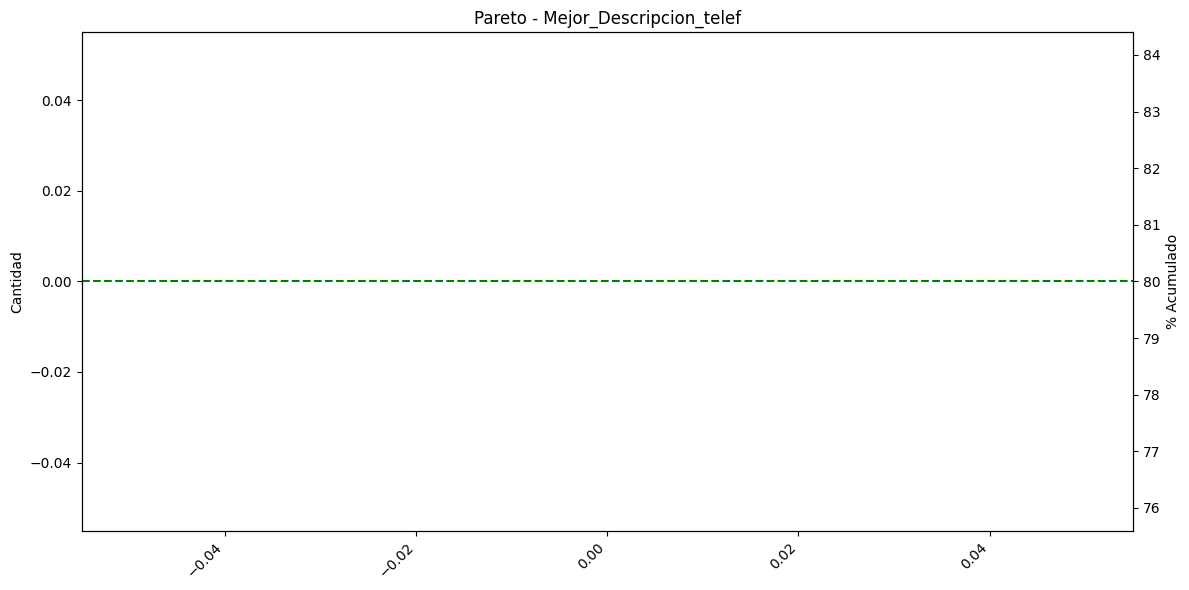

In [129]:

df_dni = df_filtrado.toPandas()
pareto_mejor_descripcion(df_dni,tipificaicon_telf)

In [48]:

exportar_lista(df_filtrado,'tc_cenco_202603301418.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]


In [ ]:
query = f"""
    SELECT
        NumDoc AS vendor_lead_code,
        marca AS title,
        ISNULL(nombre_producto, '') AS first_name,
        ISNULL(departamento, 'Sin_Departamento') AS last_name,
        nombre_largo AS address1,

        'FEC.EXP.TC' + ' ' +
        ISNULL(SUBSTRING(fecha_expiracion, 1, 4), ' ') + '-' +
        ISNULL(SUBSTRING(fecha_expiracion, 5, 2), ' ') + '-' +
        ' Numcuots: ' + ISNULL(CONVERT(VARCHAR, nrocuotas_rest), ' ')
        AS address2,

        'CICLO ' + ISNULL(CONVERT(VARCHAR, ciclo), ' ') +
        ' nro_tc:' + ISNULL(nro_tarjeta, '')
        AS address3,

        ISNULL(distrito, '') AS city,
        ISNULL(provincia, '') AS province,
        fecha_expiracion,

        'TEA PPD' + ' ' + ISNULL(CONVERT(VARCHAR, tea_formato), ' ') +
        ' TEM PPD ' + ISNULL(CONVERT(VARCHAR, tem_formato), ' ')
        AS email,

        'Oferta.PPD:' + ISNULL(CAST(saldo_ppd AS VARCHAR), '')
        AS security_phrase,

        ',Deuda_BCP: ' + ISNULL(Deuda_BCP,'') + CHAR(13) + CHAR(10) +
        ',Deuda_Continental: ' + ISNULL(Deuda_Continental,'') + CHAR(13) + CHAR(10) +
        ',Deuda_Interbank: ' + ISNULL(Deuda_Interbank,'') + CHAR(13) + CHAR(10) +
        ',Deuda_ScotiaBank: ' + ISNULL(Deuda_ScotiaBank,'') + CHAR(13) + CHAR(10) +
        ',Deuda_Falabella: ' + ISNULL(Deuda_Otros,'')

        AS comments,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(Deuda_BCP), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) AS deuda_bcp,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(Deuda_Continental), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) AS deuda_continental,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(Deuda_ScotiaBank), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) AS deuda_scotiaBank,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(Deuda_Interbank), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) AS deuda_interbank,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(Deuda_Otros), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) AS deuda_otros,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(saldo_ppd), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) AS saldo_ppd,

        CONVERT(DATE, CAST(FechaNacimiento AS VARCHAR(8))) AS fec_nac,
        TRIM(estadocivil) AS estadocivil,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(tea_formato), '%', ''), ''),
                ',', '.'
            ) AS DECIMAL(10,4)
        ) / 100 AS tea_formato,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(tem_formato), '%', ''), ''),
                ',', '.'
            ) AS DECIMAL(10,4)
        ) / 100 AS tem_formato,

        nacionalidad,
        Flag_entrega,

        CASE
            WHEN mes_entrega IS NOT NULL AND mes_entrega <> 0
                THEN CONVERT(DATE, CAST(mes_entrega AS VARCHAR(6)) + '01')
            ELSE NULL
        END AS mes_entrega,

        TRY_CAST(REPLACE(RIGHT(prioridad_inicial, 2), ' ', '') AS INT) AS prioridad_inicial,
        ciclo,
        flg_segmento_digital,

        TRY_CAST(
            REPLACE(
                NULLIF(REPLACE(TRIM(tasa_app), '-', ''), ''),
                ',', '.'
            ) AS FLOAT
        ) / 100 AS tasa_app,

        oferppd,
        oferppdplus,
        oferds,
        oferbt,
        marca2,
        marca3,
        recencia,
        linea_ei_60m,
        oferta_disef,
        oferta_ppd,
        tasappd,
        nrocuotas_rest,
        cargo,
        profesion,
        rpioridadvocales,
        estado_tarjeta,
        distrito_lab,

        CASE
            WHEN rep1 = 1 THEN 'stock'
            ELSE 'nuevo'
        END AS rep,

        fecha_envio,
        flag_adicion,

        CASE
            WHEN LEN(REPLACE(retiro, ' ', '')) > 3 THEN LOWER(REPLACE(retiro, ' ', '_'))
            ELSE 'no_aplica'
        END AS retiro,

        nombre_producto

    FROM DANTALION.dbo.Base_Maestra_Diners_Vigente
"""
df_base = obtener_tabla_sql(spark, query, server_kishin, user_kishin, pwd_kishin, db_kishin)

In [ ]:
# def since_base_maestra_pp_dinners(spark):
# query = f"""
#     Select
#         NumDoc as vendor_lead_code,
#         marca AS title,
#         ISNULL(nombre_producto,'') as first_name,
#         isnull(departamento,'Sin_Departamento') as last_name,
#         nombre_largo as address1,
#         'FEC.EXP.TC'+' '+isnull(SUBSTRING(fecha_expiracion,1,4),' ')+'-'+isnull(SUBSTRING(fecha_expiracion,5,2),' ')+'-'+ ' Numcuots: '+  isnull(CONVERT(varchar,nrocuotas_rest),' ')  AS address2,
#         'CICLO '+ isnull(CONVERT(varchar,ciclo),' ') + ' nro_tc:'+ISNULL(nro_tarjeta,'')  AS address3,
#         ISNULL(distrito,'') as city,
#         ISNULL(provincia,'') as province,
#         fecha_expiracion,
#         'TEA PPD'+' '+isnull(CONVERT(varchar,tea_formato),' ')+' TEM PPD '+isnull(CONVERT(varchar,tem_formato),' ') as email,
#         'Oferta.PPD:' + saldo_ppd AS security_phrase,
#         'TASA APP'+' '+isnull(CONVERT(varchar,tasa_app),' ')+
        ',Deuda  Deuda_BCP:'+ isnull(Deuda_BCP,0)+ 
        ',Deuda  Deuda_Continental:'+ isnull(Deuda_Continental,0)+ 
        ',Deuda  Deuda_Interbank:'+ isnull(Deuda_Interbank,0)+ 
        ',Deuda  Deuda_ScotiaBank:'+ isnull(Deuda_ScotiaBank,0)+ 
        ',Deuda  Deuda_Falabella:'+ isnull(Deuda_Otros,0) 
        as comments,
#         CONVERT(float, REPLACE(Deuda_BCP, ',', '.'))   AS deuda_bcp,
#         CONVERT(float, REPLACE(Deuda_Continental, ',', '.'))   AS deuda_continental,
#         CONVERT(float, REPLACE(Deuda_ScotiaBank, ',', '.'))   AS deuda_scotiaBank,
#         CONVERT(float, REPLACE(Deuda_Interbank, ',', '.'))   AS deuda_interbank,
#         CONVERT(float, REPLACE(Deuda_Otros, ',', '.'))   AS deuda_otros,
#         CONVERT(date, CAST(FechaNacimiento AS varchar(8))) AS fec_nac,
#         trim(estadocivil) as estadocivil,
#         CAST(
#             REPLACE(REPLACE(tea_formato, '%', ''), ',', '.') 
#             AS DECIMAL(10,4)
#         ) / 100 AS tea_formato,
#         CAST(
#             REPLACE(REPLACE(tem_formato, '%', ''), ',', '.') 
#             AS DECIMAL(10,4) 
#         ) / 100 AS tem_formato,
#         nacionalidad,
#         Flag_entrega,
#         case 
#             when mes_entrega is not null and mes_entrega<>0 then CONVERT(date, CAST(mes_entrega AS varchar(6)) + '01')
#             else null
#         end as mes_entrega,                                                     
#         cast(replace(right(prioridad_inicial,2),' ','') as int)as prioridad_inicial,ciclo,flg_segmento_digital,
#         TRY_CAST(REPLACE(NULLIF(REPLACE(TRIM(tasa_app), '-', ''),''),',','.') AS FLOAT) / 100 AS tasa_app,
#         oferppd,oferppdplus,oferds,oferbt,marca2,marca3,recencia,linea_ei_60m,oferta_disef,oferta_ppd,tasappd,saldo_ppd,nrocuotas_rest,cargo,profesion,rpioridadvocales,estado_tarjeta,distrito_lab,case when rep1=1 then 'stock' else 'nuevo' end as rep,fecha_envio,flag_adicion,
#         case
#             when len(replace(retiro,' ',''))>3  then lower(replace(retiro,' ','_'))
#             else 'no_aplica'
#         end as retiro ,
#         nombre_producto
#     FROM DANTALION.dbo.Base_Maestra_Diners_Vigente
# """
# df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

df_base = df_base.withColumn(
    "monto_deuda_max",
    greatest(
        F.col("deuda_bcp"), F.col("deuda_continental"), F.col("deuda_scotiaBank"), F.col("deuda_interbank"),
        F.col("deuda_otros")
    )
)

df_base = df_base.withColumn(
    "deuda_bench",
    F.when(F.col("monto_deuda_max") == F.col("deuda_bcp"), "deuda_bcp")
    .when(F.col("monto_deuda_max") == F.col("deuda_continental"), "deuda_continental")
    .when(F.col("monto_deuda_max") == F.col("deuda_scotiaBank"), "deuda_scotiaBank")
    .when(F.col("monto_deuda_max") == F.col("deuda_interbank"), "deuda_interbank")
    .when(F.col("monto_deuda_max") == F.col("deuda_otros"), "deuda_otros")
    .otherwise("OTROS")
)
df_base = df_base.withColumn(
    "seg_edad",
    F.when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 20) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 30), "a. 20 A 30")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 30) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 40), "b. 30 A 40")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 40) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 50), "c. 40 A 50")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 50) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 60), "d. 50 A 60")
    .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 60) &
        (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 76), "e. 60 A 70")
    .otherwise('f. Otros')
)


df_base = df_base.withColumn(
    "mes_entrega_dif",
    F.floor(
        F.months_between(
            F.current_date(),
            F.col("mes_entrega")
        )
    )
)

df_base = df_base.withColumn(
    "seg_saldo_ppd",
    F.when(F.col("saldo_ppd") < 10000, "a. [0,10k)")
    .when((F.col("saldo_ppd") >= 10000) & (F.col("saldo_ppd") < 20000), "b. [10k,20k)")
    .when((F.col("saldo_ppd") >= 20000) & (F.col("saldo_ppd") < 30000), "c. [20k,30k)")
    .when((F.col("saldo_ppd") >= 30000) & (F.col("saldo_ppd") < 40000), "d. [30k,40k)")
    .when((F.col("saldo_ppd") >= 40000) & (F.col("saldo_ppd") < 50000), "e. [40k,50k)")
    .when((F.col("saldo_ppd") >= 50000) & (F.col("saldo_ppd") < 60000), "f. [50k,60k)")
    .when((F.col("saldo_ppd") >= 60000) & (F.col("saldo_ppd") < 70000), "g. [60k,70k)")
    .when((F.col("saldo_ppd") >= 70000) & (F.col("saldo_ppd") < 80000), "h. [70k,80k)")
    .when((F.col("saldo_ppd") >= 80000) & (F.col("saldo_ppd") < 90000), "i. [80k,90k)")
    .when(F.col("saldo_ppd") >= 90000, "j. [90k,+)")
    .otherwise("z. otros")
)




df_base = df_base.withColumn(
    "seg_tea_formato",
    F.when(F.col("tea_formato") < 0.10, "a. [0%,10%)")
    .when((F.col("tea_formato") >= 0.10) & (F.col("tea_formato") < 0.15), "b. [10%,15%)")
    .when((F.col("tea_formato") >= 0.15) & (F.col("tea_formato") < 0.20), "c. [15%,20%)")
    .when((F.col("tea_formato") >= 0.20) & (F.col("tea_formato") < 0.25), "d. [20%,25%)")
    .when((F.col("tea_formato") >= 0.25) & (F.col("tea_formato") < 0.30), "e. [25%,30%)")
    .when((F.col("tea_formato") >= 0.30) & (F.col("tea_formato") < 0.35), "f. [30%,35%)")
    .when((F.col("tea_formato") >= 0.35) & (F.col("tea_formato") < 0.40), "g. [35%,40%)")
    .when((F.col("tea_formato") >= 0.40) & (F.col("tea_formato") < 0.45), "h. [40%,45%)")
    .when(F.col("tea_formato") >= 0.45, "i. [45%,+)")
    .otherwise("z. otros")
)

df_base = df_base.withColumn(
    'edad',
    F.floor(F.months_between(F.current_date(), F.col("fec_nac")) / 12)
)
    
df_base = df_base.withColumn(
    "seg_tem_formato",
    F.when(F.col("tem_formato") < 0.01, "a. [0%,1%)")
    .when((F.col("tem_formato") >= 0.01) & (F.col("tem_formato") < 0.015), "b. [1%,1.5%)")
    .when((F.col("tem_formato") >= 0.015) & (F.col("tem_formato") < 0.02), "c. [1.5%,2%)")
    .when((F.col("tem_formato") >= 0.02) & (F.col("tem_formato") < 0.025), "d. [2%,2.5%)")
    .when((F.col("tem_formato") >= 0.025) & (F.col("tem_formato") < 0.03), "e. [2.5%,3%)")
    .when(F.col("tem_formato") >= 0.03, "f. [3%,+)")
    .otherwise("z. otros")
)


df_base = df_base.withColumn(
    "seg_tasa_app",
    F.when(F.col("tasa_app") < 0.10, "a. [0%,10%)")
    .when((F.col("tasa_app") >= 0.10) & (F.col("tasa_app") < 0.15), "b. [10%,15%)")
    .when((F.col("tasa_app") >= 0.15) & (F.col("tasa_app") < 0.20), "c. [15%,20%)")
    .when((F.col("tasa_app") >= 0.20) & (F.col("tasa_app") < 0.25), "d. [20%,25%)")
    .when((F.col("tasa_app") >= 0.25) & (F.col("tasa_app") < 0.30), "e. [25%,30%)")
    .when((F.col("tasa_app") >= 0.30) & (F.col("tasa_app") < 0.35), "f. [30%,35%)")
    .when((F.col("tasa_app") >= 0.35) & (F.col("tasa_app") < 0.40), "g. [35%,40%)")
    .when(F.col("tasa_app") >= 0.40, "h. [40%,+)")
    .otherwise("z. otros")
)


In [56]:



df_base.show()

+----------------+-----+---------------+----------+--------------------+--------------------+--------------------+-----------------+----------+----------------+--------------------+----------------+--------------------+---------+-----------------+----------------+---------------+-----------+---------+----------+-----------+-----------+-----------+------------+------------+-----------+-----------------+-----+--------------------+--------+-------+-----------+------+------+-----------+------+--------+------------+------------+----------+-------+--------------+--------------------+--------------------+----------------+--------------+--------------------+-----+-----------+------------------+---------+---------------+---------------+----------------+----------+---------------+-------------+---------------+----+---------------+------------+
|vendor_lead_code|title|     first_name| last_name|            address1|            address2|            address3|             city|  province|fecha_expir

In [57]:
append_table_SQL(spark,df_base,f'borrar_dinnrs__prueba_02',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [51]:



df_base= df_base.withColumn(
    "vendor_lead_code",
    F.right(
        F.concat(F.lit("00000000"), F.col("vendor_lead_code")),
        F.lit(8)
    )
)
